# EDA - Credit Risk

Notebook inicial para explorar os dados carregados no Data Warehouse.

## Observacao

O requisito de evolucao temporal nao se aplica a este dataset, porque nao ha uma coluna de data confiavel para analisar tendencia ao longo do tempo.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv(Path('..') / '.env')
db_host = os.getenv('DB_HOST', 'localhost')
db_port = os.getenv('DB_PORT', '5432')
db_name = os.getenv('DB_NAME', 'credit_risk')
db_user = os.getenv('DB_USER', 'postgres')
db_password = os.getenv('DB_PASSWORD', '')

engine = create_engine(
    f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)

query = '''
SELECT
    f.id_aplicacao,
    c.idade,
    c.renda_anual,
    c.posse_residencia,
    c.tempo_empregada,
    p.finalidade_emprestimo,
    p.classificacao_emprestimo,
    h.inadimplencia_historica,
    h.duracao_historico_credito,
    f.montante_emprestimo,
    f.juros_aplicado,
    f.porcentagem_renda,
    f.status_emprestimo
FROM analytics.fato_emprestimo f
JOIN analytics.dim_cliente c ON c.id_cliente = f.id_cliente
JOIN analytics.dim_perfil_emprestimo p ON p.id_perfil_emprestimo = f.id_perfil_emprestimo
JOIN analytics.dim_historico_credito h ON h.id_historico_credito = f.id_historico_credito
'''

df = pd.read_sql(query, engine)
df.head()

,id_aplicacao,idade,renda_anual,posse_residencia,tempo_empregada,finalidade_emprestimo,classificacao_emprestimo,inadimplencia_historica,duracao_historico_credito,montante_emprestimo,juros_aplicado,porcentagem_renda,status_emprestimo
0,1,22,59000.0,RENT,123.0,PERSONAL,D,Y,3,35000.0,16.02,0.59,1
1,2,21,9600.0,OWN,5.0,EDUCATION,B,N,2,1000.0,11.14,0.10,0
2,3,25,9600.0,MORTGAGE,1.0,MEDICAL,C,N,3,5500.0,12.87,0.57,1
3,4,23,65500.0,RENT,4.0,MEDICAL,C,N,2,35000.0,15.23,0.53,1
4,5,24,54400.0,RENT,8.0,MEDICAL,C,Y,4,35000.0,14.27,0.55,1


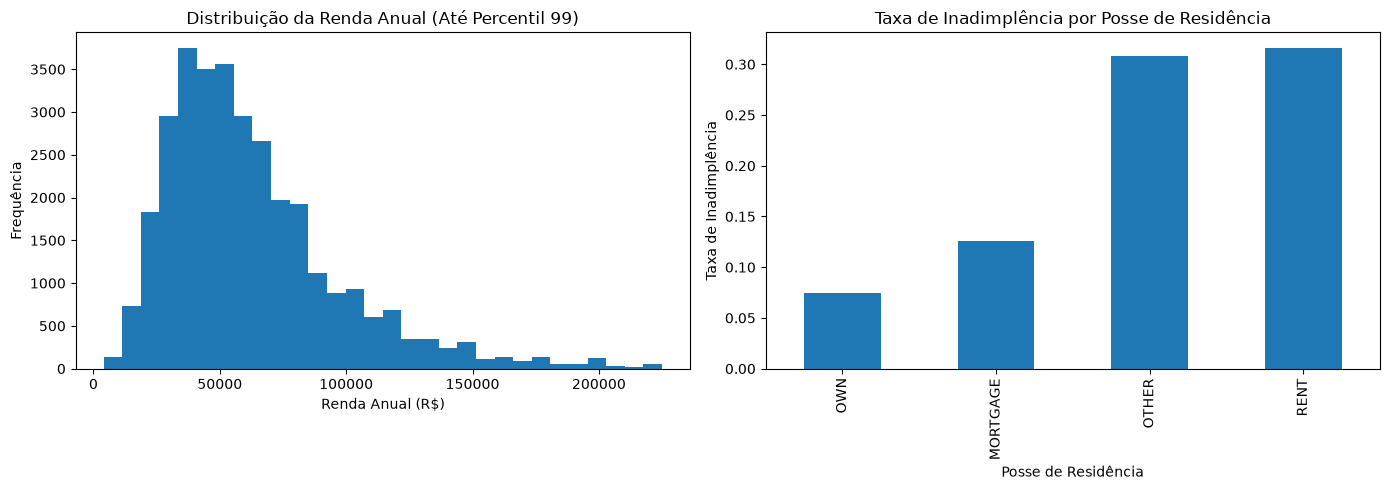

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Definir um limite superior baseado no percentil 99
limite_renda = df['renda_anual'].quantile(0.99)

# 2. Filtrar o DataFrame apenas para o plot do histograma
df_filtrado = df[df['renda_anual'] <= limite_renda]
df_filtrado['renda_anual'].plot(kind='hist', bins=30, ax=axes[0], title='Distribuição da Renda Anual (Até Percentil 99)')
axes[0].set_xlabel('Renda Anual (R$)')
axes[0].set_ylabel('Frequência')

# O gráfico de barras da inadimplência continua igual
taxa_por_residencia = df.groupby('posse_residencia')['status_emprestimo'].mean().sort_values()
taxa_por_residencia.plot(kind='bar', ax=axes[1], title='Taxa de Inadimplência por Posse de Residência')
axes[1].set_xlabel('Posse de Residência')
axes[1].set_ylabel('Taxa de Inadimplência')

plt.tight_layout()